Setup env

In [40]:
pip install nltk gensim scikit-learn numpy seaborn pyspellchecker

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: pip3.10 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [41]:
pip install --user --upgrade scipy


[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: pip3.10 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [42]:
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng') 
# nltk.download('resource_name')

[nltk_data] Downloading package punkt to /home/hlakhal-/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /home/hlakhal-/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /home/hlakhal-/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /home/hlakhal-/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /home/hlakhal-/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /home/hlakhal-/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


True

Data Exploration

In [43]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer, WordNetLemmatizer
from spellchecker import SpellChecker
from nltk import pos_tag
from nltk.corpus import wordnet
from sklearn.feature_extraction.text import CountVectorizer



In [44]:
def load_tweet_file(path):
    with open(path, 'r', encoding='utf-8', errors='replace') as f:
        content = f.read()
    if '\n' in content.strip() and content.count('\n') > 5:
        tweets = [line.strip() for line in content.split('\n') if line.strip()]
    else:
        tweets = [t.strip() for t in content.split(',') if t.strip()]
    return pd.DataFrame({'tweets': tweets})

neg = load_tweet_file('../data/processedNegative.csv')
pos = load_tweet_file('../data/processedPositive.csv')
neu = load_tweet_file('../data/processedNeutral.csv')

print(neg.shape, pos.shape, neu.shape)


(1116, 1) (1183, 1) (1566, 1)


(3865, 2)
label
Neutral     1566
Positive    1183
Negative    1116
Name: count, dtype: int64


<Axes: xlabel='label'>

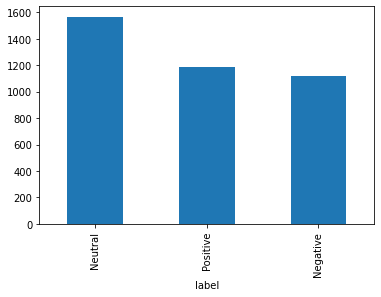

In [45]:
neg['label'] = 'Negative'
pos['label'] = 'Positive'
neu['label'] = 'Neutral'

df = pd.concat([neg, pos, neu], ignore_index=True)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print(df.shape)
print(df['label'].value_counts())

df.head()

df['label'].value_counts().plot(kind='bar')

In [46]:
df['char_length'] = df['tweets'].apply(len)

df['word_count'] = df['tweets'].apply(lambda x: len(x.split()))

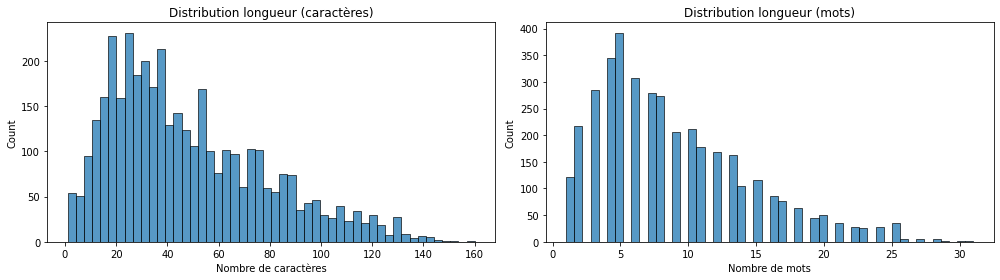

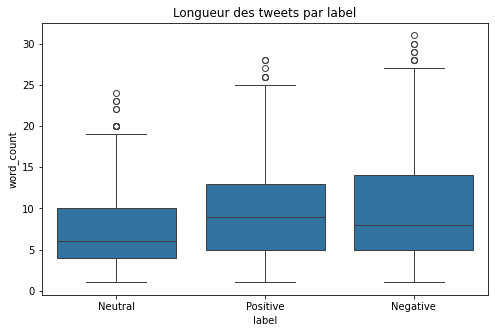

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(df['char_length'], bins=50, ax=axes[0])
axes[0].set_title('Distribution longueur (caractères)')
axes[0].set_xlabel('Nombre de caractères')

sns.histplot(df['word_count'], bins=50, ax=axes[1])
axes[1].set_title('Distribution longueur (mots)')
axes[1].set_xlabel('Nombre de mots')

plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='label', y='word_count')
plt.title('Longueur des tweets par label')
plt.show()

In [48]:
n_dup = df.duplicated(subset='tweets').sum()

duplicated_tweets = df[df.duplicated(subset='tweets', keep=False)].sort_values('tweets')
duplicated_tweets.head(10)

duplicates_check = df[df.duplicated(subset='tweets', keep=False)]
label_consistency = duplicates_check.groupby('tweets')['label'].nunique()
inconsistent = label_consistency[label_consistency > 1]

In [49]:
def basic_clean(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

In [50]:
df_clean = df.copy()
df_clean['tweets'] = df_clean['tweets'].fillna('')
df_clean = df_clean.dropna(subset=['tweets'])
df_clean['clean_tweets'] = df_clean['tweets'].apply(basic_clean)

df_clean = df_clean.drop_duplicates(subset='clean_tweets', keep='first').reset_index(drop=True)

print(df_clean.shape)

(3409, 5)


In [51]:
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

In [52]:
def tokenize_only(text):
    tokens = word_tokenize(text)
    return ' '.join(tokens)

df_clean['tokenized'] = df_clean['clean_tweets'].apply(tokenize_only)

In [53]:
def apply_stemming(text):
    tokens = word_tokenize(text)
    stemmed = [stemmer.stem(t) for t in tokens]
    return ' '.join(stemmed)

df_clean['stemmed'] = df_clean['clean_tweets'].apply(apply_stemming)

In [54]:
def get_wordnet_pos(tag):
    if tag.startswith('J'):
        return wordnet.ADJ
    elif tag.startswith('V'):
        return wordnet.VERB
    elif tag.startswith('N'):
        return wordnet.NOUN
    elif tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN

def apply_lemmatization(text):
    tokens = word_tokenize(text)
    tagged = pos_tag(tokens)
    lemmatized = [lemmatizer.lemmatize(t, get_wordnet_pos(tag)) for t, tag in tagged]
    return ' '.join(lemmatized)

df_clean['lemmatized'] = df_clean['clean_tweets'].apply(apply_lemmatization)

In [55]:
spell = SpellChecker()

def correct_spelling(text):
    tokens = text.split()
    corrected = []
    for t in tokens:
        c = spell.correction(t)
        corrected.append(c if c is not None else t)
    return ' '.join(corrected)

df_clean['spell_corrected'] = df_clean['clean_tweets'].apply(correct_spelling)

In [56]:
df_clean['stemmed_misspellings'] = df_clean['spell_corrected'].apply(apply_stemming)
df_clean['lemmatized_misspellings'] = df_clean['spell_corrected'].apply(apply_lemmatization)

In [57]:
def remove_stopwords(text):
    tokens = text.split()
    filtered = [t for t in tokens if t not in stop_words]
    return ' '.join(filtered)

df_clean['lemmatized_no_stopwords'] = df_clean['lemmatized'].apply(remove_stopwords)

In [58]:
preprocessing_variants = {
    'tokenization': df_clean['tokenized'],
    'stemming': df_clean['stemmed'],
    'lemmatization': df_clean['lemmatized'],
    'stemming_misspellings': df_clean['stemmed_misspellings'],
    'lemmatization_misspellings': df_clean['lemmatized_misspellings'],
    'lemmatization_no_stopwords': df_clean['lemmatized_no_stopwords'],
}

Similarity

In [59]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

vectorization_types = ['binary', 'count', 'tfidf']
matrix_table = pd.DataFrame(index=preprocessing_variants.keys(), columns=vectorization_types)

for name, series in preprocessing_variants.items():
    ngram_range = (1, 2) if name == 'ngrams_bigram' else (1, 1)

    binary_vec = CountVectorizer(binary=True, ngram_range=ngram_range)
    X_binary = binary_vec.fit_transform(series)

    count_vec = CountVectorizer(binary=False, ngram_range=ngram_range)
    X_count = count_vec.fit_transform(series)

    tfidf_vec = TfidfVectorizer(ngram_range=ngram_range)
    X_tfidf = tfidf_vec.fit_transform(series)

    matrix_table.loc[name, 'binary'] = X_binary
    matrix_table.loc[name, 'count'] = X_count
    matrix_table.loc[name, 'tfidf'] = X_tfidf

In [60]:
tfidf_matrix = matrix_table.loc['lemmatization_no_stopwords']['tfidf']
tfidf_similarity = cosine_similarity(tfidf_matrix)

In [61]:
def get_top_similar_pairs(similarity_matrix, texts, top_n=10):
    upper_triangle = np.triu(similarity_matrix, k=1)
    flat_indices = np.argsort(upper_triangle, axis=None)[::-1][:top_n]
    row_indices, col_indices = np.unravel_index(flat_indices, upper_triangle.shape)

    results = []
    for i, j in zip(row_indices, col_indices):
        results.append({
            'tweet_1': texts.iloc[i],
            'tweet_2': texts.iloc[j],
            'similarity': upper_triangle[i, j]
        })
    return pd.DataFrame(results)

all_top_pairs = {}

for name, texts_series in preprocessing_variants.items():
    tfidf = matrix_table.loc[name, 'tfidf']
    tfidf_similarity = cosine_similarity(tfidf)

    top10_df = get_top_similar_pairs(tfidf_similarity, texts_series, top_n=10)
    all_top_pairs[name] = top10_df

    print(f"--- Top 10 Similar Pairs for: {name} ---")
    display(top10_df)

--- Top 10 Similar Pairs for: tokenization ---


,tweet_1,tweet_2,similarity
0,thanks b happy,thanks happy,1.000000
1,i miss you unhappy,miss you unhappy,1.000000
2,thanks,thanks d,1.000000
3,hi we tried to call your number but got no res...,hi we tried to call your number but got no res...,0.994466
4,hi we tried to call your number but got no res...,hi we tried to call your number but got no res...,0.980540
5,hey thanks for being top new followers this we...,hey thanks for being my top new followers this...,0.980193
6,hi we tried to call your number but got no res...,hi we tried to call your number but got no res...,0.975198
7,and more also in epaper,and more also in the epaper,0.962719
8,in tamil nadu,tamil nadu,0.961788
9,share the love thanks for being top new follow...,share the love thanks for being top new follow...,0.954925


--- Top 10 Similar Pairs for: stemming ---


,tweet_1,tweet_2,similarity
0,i miss you unhappi,miss you unhappi,1.000000
1,thank,thank d,1.000000
2,babi unhappi,babi unhappi,1.000000
3,thank b happi,thank happi,1.000000
4,hi we tri to call your number but got no respo...,hi we tri to call your number but got no respo...,0.993940
5,stat for the day have arriv new follow and no ...,stat for the day have arriv to new follow and ...,0.990837
6,hi we tri to call your number but got no respo...,hi we tri to call your number but got no respo...,0.978788
7,hey thank for be top new follow thi week much ...,hey thank for be my top new follow thi week mu...,0.977987
8,hi we tri to call your number but got no respo...,hi we tri to call your number but got no respo...,0.972958
9,and more also in epap,and more also in the epap,0.962719


--- Top 10 Similar Pairs for: lemmatization ---


...

,tweet_1,tweet_2,similarity
0,babi unhappi,babi unhappi,1.000000
1,a unhappi i miss you too,i miss you too unhappi,1.000000
2,i miss you unhappi,miss you unhappi,1.000000
3,thank b happi,thank happi,1.000000
4,oh,oh,1.000000
5,mayb i do,mayb i do n't,1.000000
6,thank,thank d,1.000000
7,hi we tri to call your number but got no respo...,hi we tri to call your number but got no respo...,0.993881
8,stat for the day have arriv new follow and no ...,stat for the day have arriv to new follow and ...,0.991305
9,hi we tri to call your number but got no respo...,hi we tri to call your number but got no respo...,0.978985


--- Top 10 Similar Pairs for: lemmatization_misspellings ---


,tweet_1,tweet_2,similarity
0,maybe i do,maybe i do n't,1.000000
1,baby unhappy,baby unhappy,1.000000
2,a unhappy i miss you too,i miss you too unhappy,1.000000
3,i miss you unhappy,miss you unhappy,1.000000
4,thanks,thanks d,1.000000
5,oh,oh,1.000000
6,thanks b happy,thanks happy,1.000000
7,hi we try to call your number but get no respo...,hi we try to call your number but get no respo...,0.995856
8,hi we try to call your number but get no respo...,hi we try to call your number but get no respo...,0.993879
9,stats for the day have arrive new follower and...,stats for the day have arrive to new follower ...,0.992488


--- Top 10 Similar Pairs for: lemmatization_no_stopwords ---


,tweet_1,tweet_2,similarity
0,thanks recent follow happy connect happy great...,thanks recent follow happy connect happy great...,1.0
1,miss unhappy,miss unhappy,1.0
2,also epaper,also epaper,1.0
3,miss unhappy,miss unhappy,1.0
4,miss unhappy,miss unhappy,1.0
5,miss unhappy,miss unhappy,1.0
6,miss unhappy,miss unhappy,1.0
7,miss unhappy,miss unhappy,1.0
8,also epaper,also epaper,1.0
9,also epaper,also epaper,1.0


In [62]:
mask = df_clean['lemmatized_no_stopwords'] == 'miss unhappy'
print(df_clean.loc[mask, 'tweets'].tolist())

['I miss you unhappy', 'i miss them unhappy', 'I miss you more unhappy', 'I miss him unhappy', 'i miss you too unhappy', 'miss you unhappy']


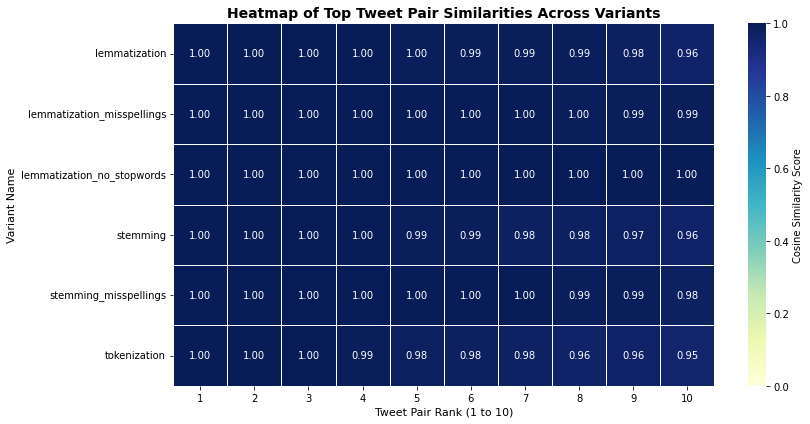

In [63]:
heatmap_data = []
for name, top10_df in all_top_pairs.items():
    temp_df = top10_df.copy()
    temp_df['variant'] = name
    temp_df['pair_rank'] = range(1, len(temp_df) + 1)
    heatmap_data.append(temp_df[['variant', 'pair_rank', 'similarity']])

combined_df = pd.concat(heatmap_data)

pivot_df = combined_df.pivot(index='variant', columns='pair_rank', values='similarity')

plt.figure(figsize=(12, 6))
sns.heatmap(
    pivot_df, 
    annot=True,          
    fmt=".2f",           
    cmap="YlGnBu",
    cbar_kws={'label': 'Cosine Similarity Score'},
    linewidths=.5,
    vmin=0, vmax=1.0
)

plt.title('Heatmap of Top Tweet Pair Similarities Across Variants', fontsize=14, fontweight='bold')
plt.xlabel('Tweet Pair Rank (1 to 10)', fontsize=11)
plt.ylabel('Variant Name', fontsize=11)
plt.tight_layout()
plt.show()

Train ~ Test Split

In [66]:
from sklearn.model_selection import  train_test_split

X_train, X_test, y_train, y_test = train_test_split(tfidf_matrix, df_clean['label'], test_size=0.2, random_state=42)


Machine learning

In [72]:
from sklearn.linear_model import  LogisticRegression
from sklearn.metrics import  accuracy_score

model = LogisticRegression()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

acc = accuracy_score(y_test,y_pred)

print(f'Accuracy Score: {acc}')
print()

Accuracy Score: 0.8504398826979472



In [ ]:
print(y_pred)

['Negative' 'Neutral' 'Neutral' 'Positive' 'Positive' 'Neutral' 'Neutral'
 'Positive' 'Neutral' 'Neutral' 'Neutral' 'Neutral' 'Positive' 'Negative'
 'Negative' 'Neutral' 'Neutral' 'Neutral' 'Positive' 'Neutral' 'Positive'
 'Negative' 'Negative' 'Negative' 'Neutral' 'Neutral' 'Negative' 'Neutral'
 'Neutral' 'Positive' 'Positive' 'Neutral' 'Neutral' 'Neutral' 'Negative'
 'Neutral' 'Negative' 'Negative' 'Negative' 'Neutral' 'Neutral' 'Neutral'
 'Neutral' 'Negative' 'Negative' 'Neutral' 'Positive' 'Positive' 'Neutral'
 'Neutral' 'Neutral' 'Negative' 'Neutral' 'Neutral' 'Neutral' 'Neutral'
 'Neutral' 'Neutral' 'Neutral' 'Negative' 'Negative' 'Neutral' 'Neutral'
 'Positive' 'Positive' 'Neutral' 'Negative' 'Neutral' 'Neutral' 'Positive'
 'Neutral' 'Neutral' 'Positive' 'Neutral' 'Negative' 'Neutral' 'Neutral'
 'Negative' 'Neutral' 'Positive' 'Neutral' 'Positive' 'Negative' 'Neutral'
 'Positive' 'Positive' 'Neutral' 'Neutral' 'Positive' 'Negative'
 'Positive' 'Positive' 'Neutral' 'Negative' 'Ne